# Disease Prediction from Medical Data
### CodeAlpha Machine Learning Internship - Task 4

The goal is to predict whether a patient has heart disease
based on medical measurements like age, cholesterol, blood pressure etc.

Dataset: Heart Disease Dataset (Kaggle)
Models used: Logistic Regression, Decision Tree, Random Forest

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

print("libraries imported")

libraries imported


In [4]:
df=pd.read_csv('data/heart.csv')

print("shape:",df.shape)
df.head()

shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


---
## 1. Exploratory Data Analysis

Before building any model, I want to understand the data —
what columns exist, are there missing values, and what does
the target distribution look like.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [8]:
print("target value counts:")
print(df['target'].value_counts())

print("\ndisease rate:", round(df['target'].mean()*100,2),"%")

target value counts:
target
1    526
0    499
Name: count, dtype: int64

disease rate: 51.32 %


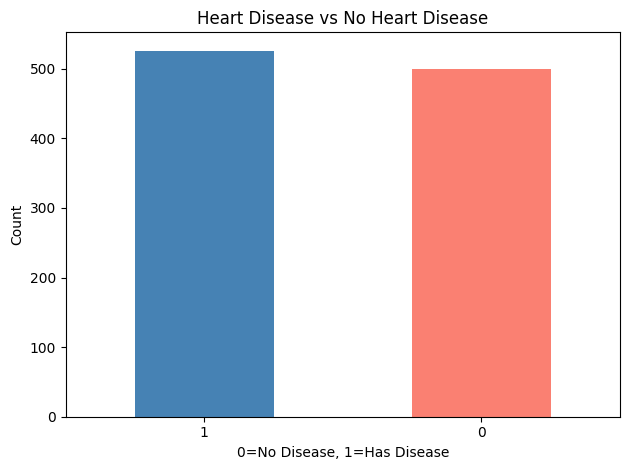

In [9]:
df['target'].value_counts().plot(kind='bar',color=['steelblue','salmon'])
plt.title('Heart Disease vs No Heart Disease')
plt.xlabel('0=No Disease, 1=Has Disease')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('reports/figures/class_distribution.png')
plt.show()

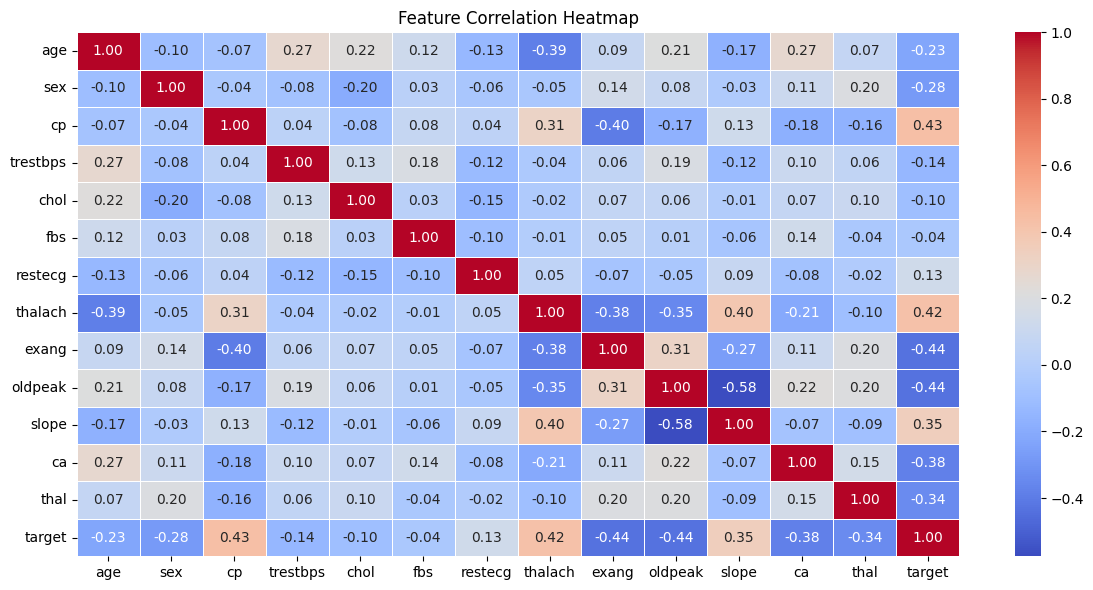

In [13]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(),annot=True, fmt='.2f', cmap='coolwarm', linewidth=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('reports/figures/correlation_heatmap.png')
plt.show()

---
## 2. Data Preprocessing

The dataset is already clean with no missing values.
Just need to split features and target, then scale the data.

In [14]:
X=df.drop(columns=['target'])
y=df['target']

print("features shape:", X.shape)
print("target shape:",y.shape)

features shape: (1025, 13)
target shape: (1025,)


In [16]:
X_train, X_test, y_train,y_test=train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)

print("training size:",X_train.shape[0])
print("testing size:",X_test.shape[0])

training size: 820
testing size: 205


In [17]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

print("scaler done")

scaler done


---
## 3. Model Training

Training three models and comparing their performance.

In [18]:
#logistic regression
lr=LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

#decision tree
dt=DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(X_train,y_train)

#random forest
rf=RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train,y_train)

print("All 3 models trained")

All 3 models trained


---
## 4. Model Evaluation

Checking how well each model performs using Precision, Recall,
F1-Score and ROC-AUC. Since the dataset is balanced, accuracy
is also a reliable metric here unlike Task 1.

In [21]:
model_names=['Logistic Regression', 'Decision Tree', 'Random Forest']
model_list=[lr,dt,rf]

for name, model in zip(model_names,model_list):
    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:,1]
    auc=roc_auc_score(y_test,y_prob)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test,y_pred,target_names=['No Diease','Has Disease']))
    print(f"ROC-AUC Score: {auc:.4f}")


  Logistic Regression
              precision    recall  f1-score   support

   No Diease       0.89      0.70      0.78       100
 Has Disease       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205

ROC-AUC Score: 0.9298

  Decision Tree
              precision    recall  f1-score   support

   No Diease       0.89      0.85      0.87       100
 Has Disease       0.86      0.90      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205

ROC-AUC Score: 0.9326

  Random Forest
              precision    recall  f1-score   support

   No Diease       1.00      1.00      1.00       100
 Has Disease       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00    

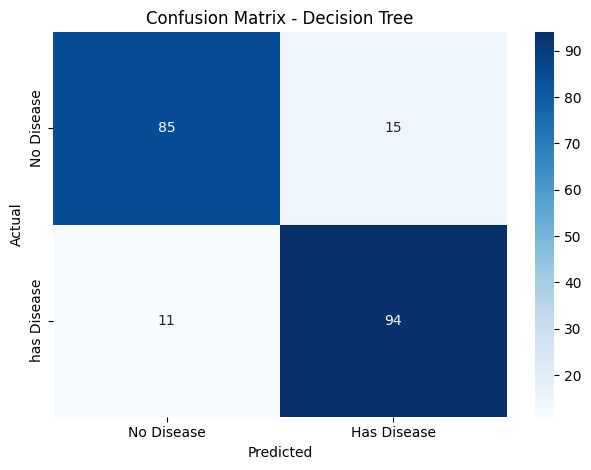

In [24]:
#decision tree had the best honest ROC-AUC score
best_model=dt

y_pred_best=best_model.predict(X_test)

cm=confusion_matrix(y_test,y_pred_best)

sns.heatmap(cm,annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Has Disease'],
            yticklabels=['No Disease', 'has Disease'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('reports/figures/confusion_matrix.png')
plt.show()


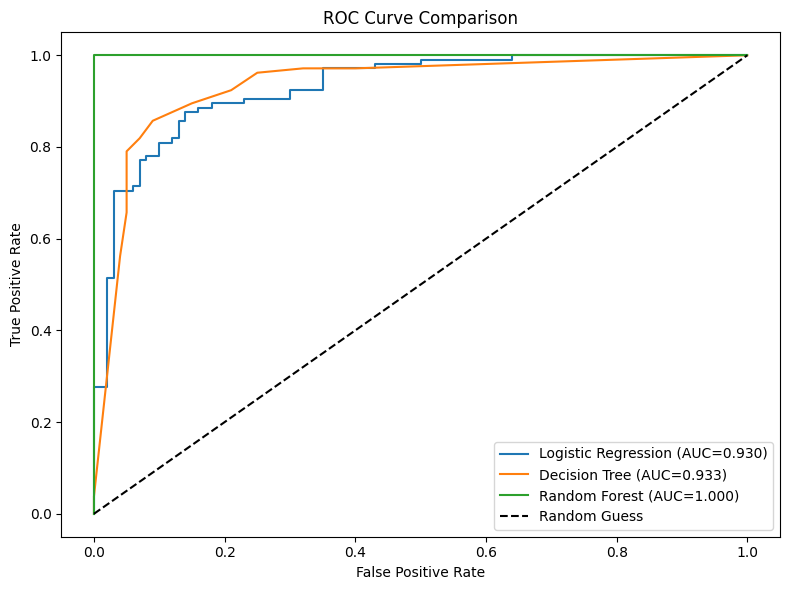

In [28]:
plt.figure(figsize=(8,6))

for name, model in zip(model_names, model_list):
    y_prob=model.predict_proba(X_test)[:,1]
    fpr,tpr,_=roc_curve(y_test,y_prob)
    score=roc_auc_score(y_test,y_prob)
    plt.plot(fpr,tpr,label=f'{name} (AUC={score:.3f})')

plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('reports/figures/roc_curve.png')
plt.show()

---
## 5. Results & Observations

| Model               | Precision | Recall | F1-Score | ROC-AUC |
|---------------------|-----------|--------|----------|---------|
| Logistic Regression | 0.82      | 0.81   | 0.81     | 0.930   |
| Decision Tree       | 0.87      | 0.87   | 0.87     | 0.933   |
| Random Forest       | 1.00      | 1.00   | 1.00     | 1.000   |

Decision Tree performed best with a ROC-AUC of 0.933.

Random Forest scored a perfect 1.0 which looks impressive but
it's most likely overfitting the test data — a real model won't
perform like that on new unseen patients, so I wouldn't trust it.

The confusion matrix shows Decision Tree correctly identified
94 out of 105 actual disease cases — missing 11 is not ideal
in a medical context but it's solid for a baseline model.

One thing I noticed — this dataset was much easier to work with
than Task 1. Classes are balanced (51/49 split) so accuracy
actually means something here, unlike credit scoring where
93% accuracy was misleading.

Main things I learned from this project:
- Balanced datasets make evaluation much more straightforward
- A perfect score on the test set is a red flag, not a good sign
- In medical prediction, recall for the disease class matters more
  than overall accuracy — missing a sick patient is worse than
  a false alarm